In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

In [2]:
data = np.load('creditcard_preprocessed.npz')

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (341178, 29), Validation shape: (113726, 29), Test shape: (113726, 29)


In [3]:
# Hyperparameter tuning - Find optimal K
error_rate = []
k_values = range(1, 31)

print("Starting hyperparameter tuning on Validation Set...")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Train on Training data
    knn.fit(X_train, y_train)
    
    # Predict on Validation data
    y_pred_val = knn.predict(X_val)
    
    # Calculate Error Rate (1 - Accuracy)
    error = 1 - accuracy_score(y_val, y_pred_val)
    error_rate.append(error)
    
    if k % 5 == 0:
        print(f"K={k}, Validation Error: {error:.4f}")

# Find the K with the minimum error
optimal_k = k_values[np.argmin(error_rate)]
min_error = np.min(error_rate)

print(f"\nOptimal K found: {optimal_k} with minimum Validation Error: {min_error:.4f}")

Starting hyperparameter tuning on Validation Set...
K=5, Validation Error: 0.0027
K=10, Validation Error: 0.0037
K=15, Validation Error: 0.0052
K=20, Validation Error: 0.0057
K=25, Validation Error: 0.0069
K=30, Validation Error: 0.0073

Optimal K found: 2 with minimum Validation Error: 0.0010


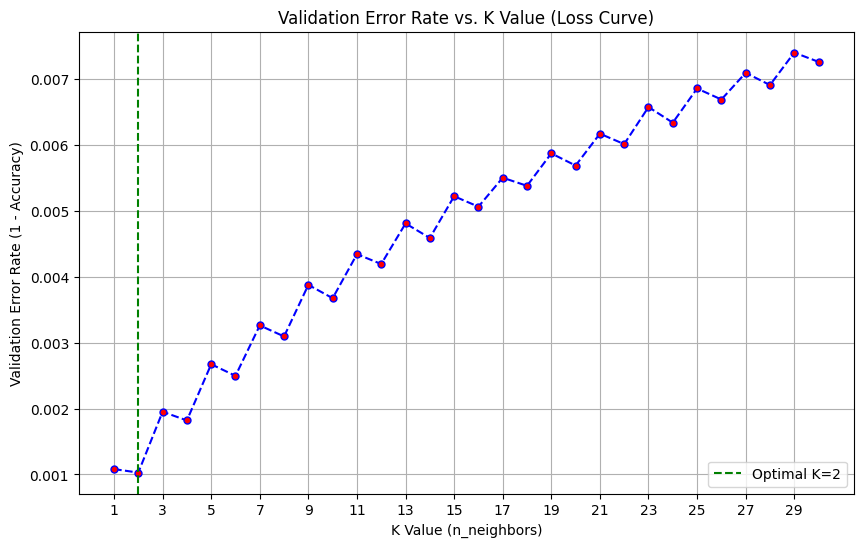

In [4]:
# Plot Validation Error Rate vs. K
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=5)
plt.title('Validation Error Rate vs. K Value (Loss Curve)')
plt.xlabel('K Value (n_neighbors)')
plt.ylabel('Validation Error Rate (1 - Accuracy)')
plt.xticks(k_values[::2])
plt.axvline(x=optimal_k, color='g', linestyle='--', label=f'Optimal K={optimal_k}')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
# Train final model with optimal K and evaluate on Test Set
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)

# Predictions
y_pred_test = final_knn.predict(X_test)
y_pred_prob = final_knn.predict_proba(X_test)[:, 1]  # For ROC curve

accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test Set Accuracy (Optimal K={optimal_k}): {accuracy:.4f}")

Test Set Accuracy (Optimal K=2): 0.9987


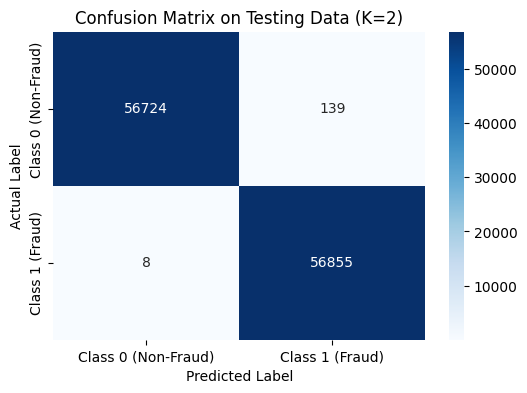

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0 (Non-Fraud)', 'Class 1 (Fraud)'],
            yticklabels=['Class 0 (Non-Fraud)', 'Class 1 (Fraud)'])
plt.title(f'Confusion Matrix on Testing Data (K={optimal_k})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

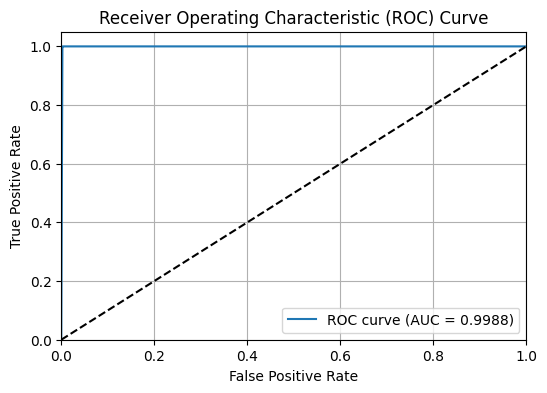

In [7]:
# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()